# Fronts

This notebook is meant to help forcasters locate the position of fronts on a weather map

In [76]:
from herbie import Herbie
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.weight"] = "heavy"
from toolbox import EasyMap, pc
import cartopy.crs as ccrs
import cartopy.feature as feature
import pandas as pd

from matplotlib.patches import Rectangle
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pytz
import os, shutil
import json

from scipy.ndimage import gaussian_filter

import warnings

# supress because removal of old datafiles is handled outside herbie
warnings.filterwarnings("ignore")

from bmwflib import (
    clear_directory,
    get_var,
    make_figure,
    plot_cities,
    make_title,
    plot_pressure,
    find_pressure_centres,
)

%load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


In [2]:
# time of last model run (0Z and 12Z)
now = pd.Timestamp.utcnow().floor("12h").tz_localize(None)
fxx = 6

# config determines the directories in which to save each graphic
with open("..//config/gdps_config.json") as f:
    config = json.load(f)

clear_dir = [clear_directory(file) for file in list(config["plots"].values())]

In [41]:
# heights to pull geopotentials
hgt = ["ISBL_1000", "ISBL_500"]

height = xr.concat(
    [get_var(now, "gdps", fxx, "HGT", h) for h in hgt],
    dim="isobaricInhPa",
)
pres = get_var(now, "gdps", fxx, "PRMSL", "MSL_0")
ds = xr.merge([pres, height])
# calculate 1000 - 500mb thickness
ds["thick"] = ds.gh.loc[{"isobaricInhPa": 500}] - ds.gh.loc[{"isobaricInhPa": 1000}]

✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None


In [54]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:              (latitude: 287, longitude: 554, isobaricInhPa: 2)
Coordinates:
    time                 datetime64[ns] 8B 2025-11-09T12:00:00
    step                 timedelta64[ns] 8B 06:00:00
    meanSea              float64 8B 0.0
  * latitude             (latitude) float64 2kB 30.0 30.15 30.3 ... 72.75 72.9
  * longitude            (longitude) float64 4kB -180.0 -179.8 ... -97.2 -97.05
    valid_time           datetime64[ns] 8B 2025-11-09T18:00:00
    gribfile_projection  object 8B None
  * isobaricInhPa        (isobaricInhPa) float64 16B 1e+03 500.0
Data variables:
    prmsl                (latitude, longitude) float32 636kB ...
    gh                   (isobaricInhPa, latitude, longitude) float32 1MB 156...
    thick                (latitude, longitude) float32 636kB 5.712e+03 ... 5....
    mag_500              (latitude, longitude) float32 636kB 1.118 ... 1.581
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    model:                   gdps
    product:                 15km/grib2/lat_lon
    description:             Canada's Global Deterministic Prediction System ...
    remote_grib:             /Users/andrew/data/gdps/20251109/CMC_glb_PRMSL_M...
    local_grib:              /Users/andrew/data/gdps/20251109/CMC_glb_PRMSL_M...
    search:                  None

We want to find areas where there is a steep temperature gradient and steep intersection angle between isobars and lines of constant thickness. do this by taking the dot product of the gradients and comparing to some threshhold angle:

$$
\nabla geopotential \cdot \nabla thickness < \theta_t
$$

and filter by areas where the thickness gradient is steep enough to warrant trying to draw a front in the first place:

$$
|\nabla thickness | > \alpha
$$

In [82]:
# calculate the gradient of the 500mb geopotential surface and its magnitude
grad_500 = np.gradient(ds.gh.loc[{"isobaricInhPa": 500}])
mag_500 = (grad_500[0] ** 2 + grad_500[1] ** 2) ** 0.5

# calculate the gradient of 1000-500mb thickness and its magnitude
grad_thick = np.gradient(ds.thick)
mag_thick = (grad_thick[0] ** 2 + grad_thick[1] ** 2) ** 0.5

# applly a gaussian filter to smooth both fields before calculating
sigma = 10
# grad_500 = gaussian_filter(grad_500, sigma=sigma)
grad_thick = gaussian_filter(grad_500, sigma=sigma)


# get the dot product of thickness gradient and geopotential gradient, then get the angle between gradients
dot = grad_500[0] * grad_thick[0] + grad_500[1] * grad_thick[1]
theta = np.arccos(dot / (mag_500 * mag_thick))

# convert to xarray
ds["mag_thick"] = xr.DataArray(mag_thick, coords=(ds.latitude, ds.longitude))
ds["theta"] = xr.DataArray(theta, coords=(ds.latitude, ds.longitude))

<a list of 19 text.Text objects>

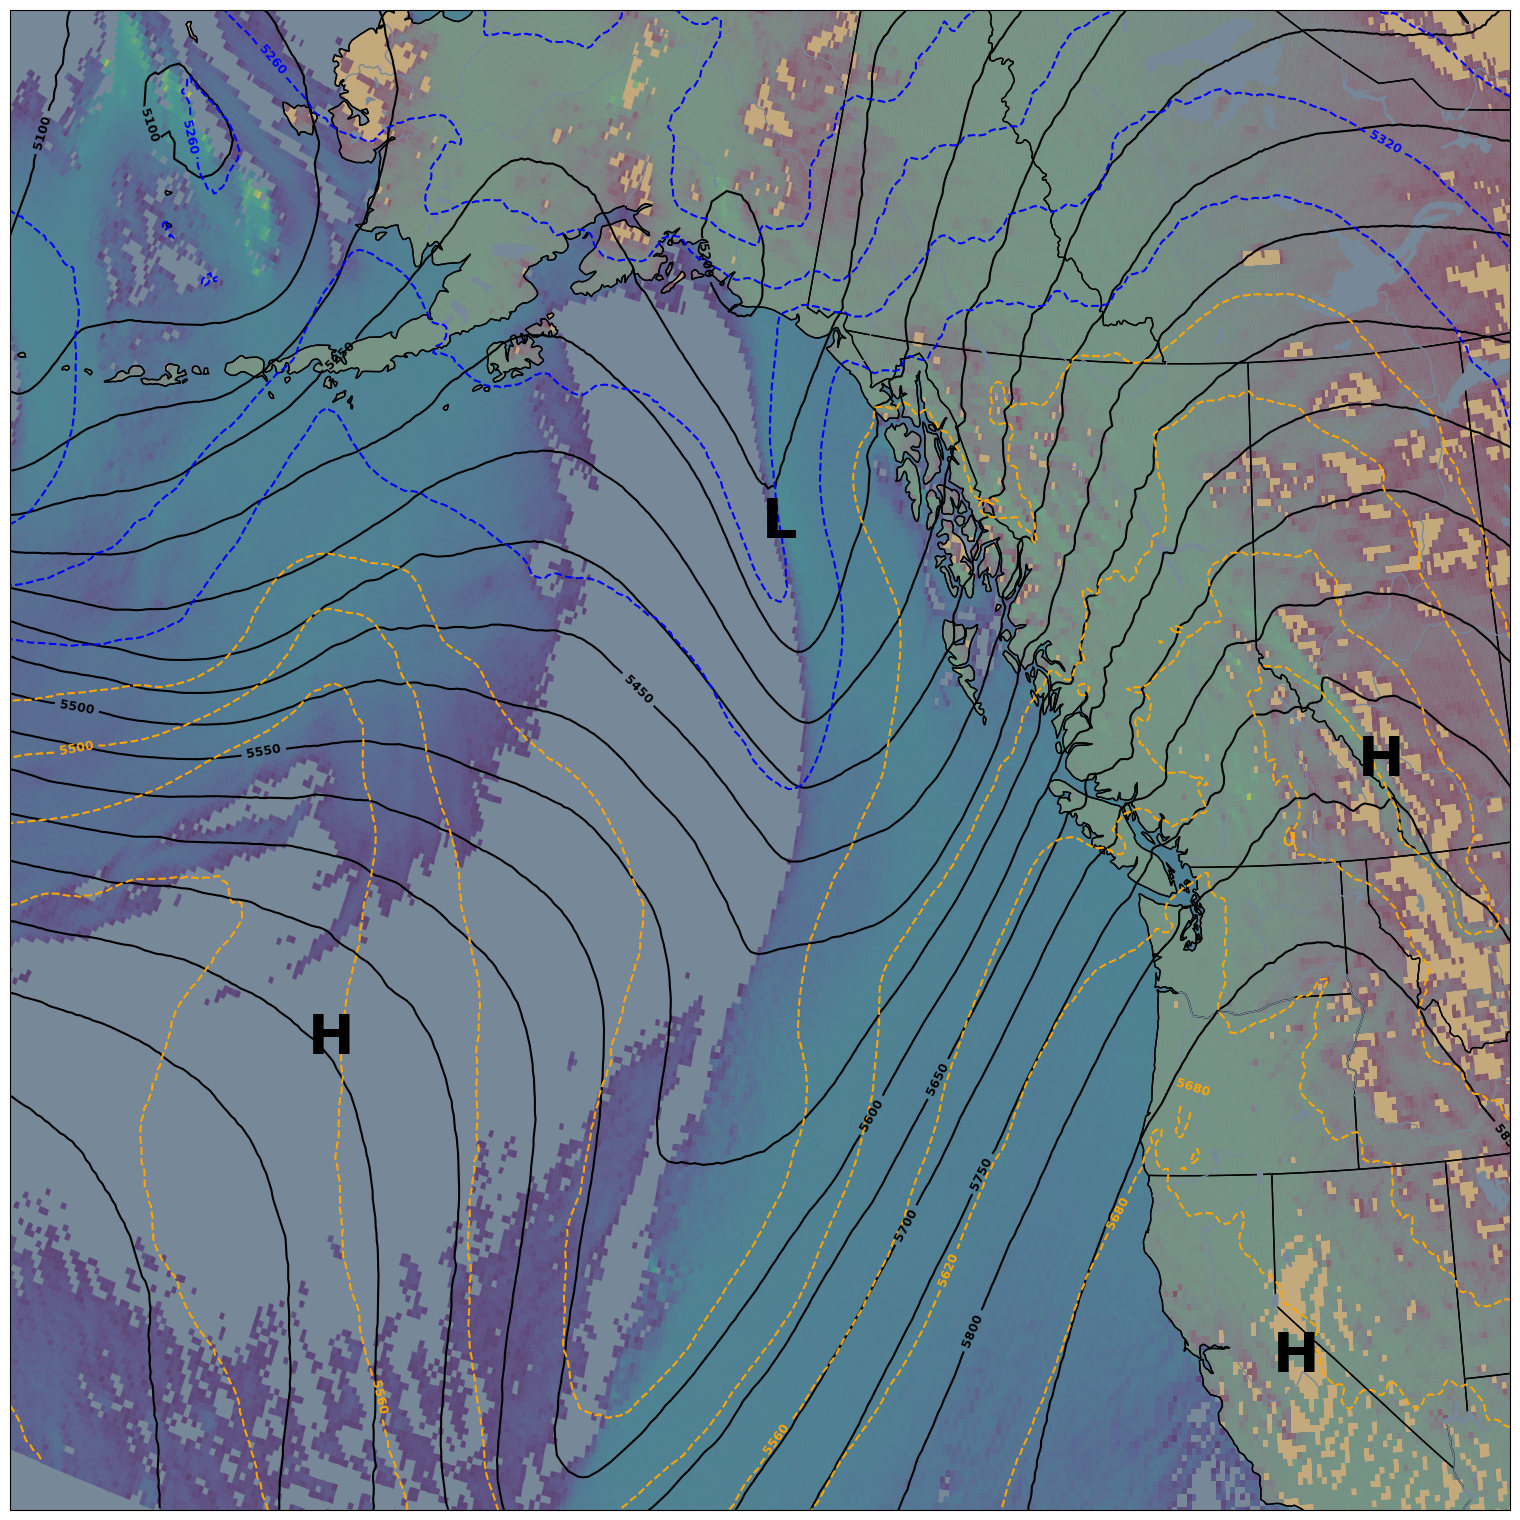

In [83]:
fig, ax = make_figure()

# plot 500mb pressure
plot_pressure(
    ds.gh.loc[{"isobaricInhPa": 500}],
    ax,
    "MWF",
    radius=90,
    delrad=40,
    levels=range(0, 8000, 50),
)

# plot areas where the angle bw thickness and height is > theta
theta = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.theta.where(ds.theta >= 30 * (np.pi / 180)),
    antialiased=True,
    transform=pc,
    alpha=0.5,
)

# plot thickness contours
th_cmap = mpl.colors.ListedColormap(
    [
        "pink",
        "blue",
        "orange",
    ]
)
th_bounds = [4800, 5100, 5400, 5700]
th_norm = mpl.colors.BoundaryNorm(th_bounds, th_cmap.N)
ht = ax.contour(
    ds.longitude,
    ds.latitude,
    ds.thick,
    cmap=th_cmap,
    norm=th_norm,
    linestyles="dashed",
    transform=pc,
    levels=range(4000, 6000, 60),
)
ax.clabel(ht, inline=True, fontsize=9)